# Clasificación de Piso en el Dataset UJIIndoorLoc usando Redes Neuronales Artificiales (ANN)

---

## Introducción

En este notebook se replica el flujo de análisis implementado previamente para la clasificación del **piso** en un entorno interior utilizando el dataset **UJIIndoorLoc**, pero en esta ocasión aplicando un modelo de **red neuronal artificial** con capas completamente conectadas (Fully Connected – FC).

El conjunto de datos UJIIndoorLoc contiene mediciones de señales WiFi tomadas en diferentes ubicaciones dentro de un edificio, junto con información asociada como coordenadas, piso, usuario y timestamp. Nuestro objetivo sigue siendo predecir el **piso** en el que se encuentra un dispositivo, tratando el problema como una clasificación multiclase (planta baja, primer piso, segundo piso, etc.).

## Objetivos

- **Cargar y explorar** el conjunto de datos UJIIndoorLoc.
- **Preparar** los datos seleccionando las características relevantes y la variable objetivo (`FLOOR`).
- **Dividir** el dataset en entrenamiento y validación (80/20).
- **Construir** una red neuronal totalmente conectada (fully connected ANN) para clasificar el piso.
- **Diseñar y ajustar** la arquitectura de la red (número de capas, unidades por capa, funciones de activación, etc.).
- **Evaluar el desempeño** del modelo en el conjunto de validación mediante métricas como *accuracy*, *precision*, *recall*, y *F1-score*.
- **Comparar los resultados** obtenidos con los modelos clásicos de clasificación entrenados anteriormente.

Este ejercicio permite evaluar la capacidad de generalización de una red neuronal densa sobre datos del mundo real, comparando su desempeño con algoritmos tradicionales y practicando buenas prácticas en diseño, entrenamiento y evaluación de modelos neuronales.

---


## Descripción del Dataset

El dataset utilizado en este análisis es el **UJIIndoorLoc Dataset**, ampliamente utilizado para tareas de localización en interiores a partir de señales WiFi. Está disponible públicamente en la UCI Machine Learning Repository y ha sido recopilado en un entorno real de un edificio universitario.

Cada muestra corresponde a una observación realizada por un dispositivo móvil, donde se registran las intensidades de señal (RSSI) de más de 500 puntos de acceso WiFi disponibles en el entorno. Además, cada fila contiene información contextual como la ubicación real del dispositivo (coordenadas X e Y), el piso, el edificio, el identificador del usuario, y la marca temporal.

El objetivo en esta tarea es predecir el **piso** (`FLOOR`) en el que se encontraba el dispositivo en el momento de la medición, considerando únicamente las características numéricas provenientes de las señales WiFi.

### Estructura del dataset

- **Número de muestras**: ~20,000
- **Número de características**: 520
  - 520 columnas con valores de intensidad de señal WiFi (`WAP001` a `WAP520`)
- **Variable objetivo**: `FLOOR` (variable categórica con múltiples clases, usualmente entre 0 y 4)

### Columnas relevantes

- `WAP001`, `WAP002`, ..., `WAP520`: niveles de señal recibida desde cada punto de acceso WiFi (valores entre -104 y 0, o 100 si no se detectó).
- `FLOOR`: clase objetivo a predecir (nivel del edificio).
- (Otras columnas como `BUILDINGID`, `SPACEID`, `USERID`, `TIMESTAMP`, etc., pueden ser ignoradas o utilizadas en análisis complementarios).

### Contexto del problema

La localización en interiores es un problema complejo en el que tecnologías como el GPS no funcionan adecuadamente. Los sistemas basados en WiFi han demostrado ser una alternativa efectiva para estimar la ubicación de usuarios en edificios. Poder predecir automáticamente el piso en el que se encuentra una persona puede mejorar aplicaciones de navegación en interiores, accesibilidad, gestión de emergencias y servicios personalizados. Este tipo de problemas es típicamente abordado mediante algoritmos de clasificación multiclase.


### Estrategia de evaluación

En este análisis seguiremos una metodología rigurosa para garantizar la validez de los resultados:

1. **Dataset de entrenamiento**: Se utilizará exclusivamente para el desarrollo, entrenamiento y optimización de hiperparámetros de todos los modelos. Este conjunto será dividido internamente en subconjuntos de entrenamiento y validación (80/20) para la selección de hiperparámetros mediante validación cruzada.

2. **Dataset de prueba**: Se reservará únicamente para la **evaluación final** de los modelos ya optimizados. Este conjunto **no debe ser utilizado** durante el proceso de selección de hiperparámetros, ajuste de modelos o toma de decisiones sobre la arquitectura, ya que esto introduciría sesgo y comprometería la capacidad de generalización estimada.

3. **Validación cruzada**: Para la optimización de hiperparámetros se empleará validación cruzada 5-fold sobre el conjunto de entrenamiento, lo que permitirá una estimación robusta del rendimiento sin contaminar los datos de prueba.

Esta separación estricta entre datos de desarrollo y evaluación final es fundamental para obtener una estimación realista del rendimiento que los modelos tendrían en un escenario de producción con datos completamente nuevos.

---


## Paso 1: Cargar y explorar el dataset

**Instrucciones:**
- Descarga el dataset **UJIIndoorLoc** desde la UCI Machine Learning Repository o utiliza la versión proporcionada en el repositorio del curso (por ejemplo: `datasets\UJIIndoorLoc\trainingData.csv`).
- Carga el dataset utilizando `pandas`.
- Muestra las primeras filas del dataset utilizando `df.head()`.
- Imprime el número total de muestras (filas) y características (columnas).
- Verifica cuántas clases distintas hay en la variable objetivo `FLOOR` y cuántas muestras tiene cada clase (`df['FLOOR'].value_counts()`).


In [16]:
import pandas as pd

# Cargar el dataset original
# Asegúrate de que el archivo trainingData.csv esté en la misma carpeta que tu notebook
df = pd.read_csv('/content/trainingData (1).csv')

# Exploración de dimensiones y clases
print(f"Número de muestras: {df.shape[0]}")
print(f"Número de características: {df.shape[1]}")
print("\nDistribución de muestras por piso (FLOOR):")
print(df['FLOOR'].value_counts().sort_index())

# Mostrar las primeras filas
df.head()

Número de muestras: 19937
Número de características: 529

Distribución de muestras por piso (FLOOR):
FLOOR
0    4369
1    5002
2    4416
3    5048
4    1102
Name: count, dtype: int64


,WAP001,WAP002,WAP003,WAP004,WAP005,WAP006,WAP007,WAP008,WAP009,WAP010,...,WAP520,LONGITUDE,LATITUDE,FLOOR,BUILDINGID,SPACEID,RELATIVEPOSITION,USERID,PHONEID,TIMESTAMP
0,100,100,100,100,100,100,100,100,100,100,...,100,-7541.2643,4.864921e+06,2,1,106,2,2,23,1371713733
1,100,100,100,100,100,100,100,100,100,100,...,100,-7536.6212,4.864934e+06,2,1,106,2,2,23,1371713691
2,100,100,100,100,100,100,100,-97,100,100,...,100,-7519.1524,4.864950e+06,2,1,103,2,2,23,1371714095
3,100,100,100,100,100,100,100,100,100,100,...,100,-7524.5704,4.864934e+06,2,1,102,2,2,23,1371713807
4,100,100,100,100,100,100,100,100,100,100,...,100,-7632.1436,4.864982e+06,0,0,122,2,11,13,1369909710


---

## Paso 2: Preparar los datos

**Instrucciones:**

- Elimina las columnas que no son relevantes para la tarea de clasificación del piso:
  - `LONGITUDE`, `LATITUDE`, `SPACEID`, `RELATIVEPOSITION`, `USERID`, `PHONEID`, `TIMESTAMP`
- Conserva únicamente:
  - Las columnas `WAP001` a `WAP520` como características (RSSI de puntos de acceso WiFi).
  - La columna `FLOOR` como variable objetivo.
- Verifica si existen valores atípicos o valores inválidos en las señales WiFi (por ejemplo: valores constantes como 100 o -110 que suelen indicar ausencia de señal).
- Separa el conjunto de datos en:
  - `X`: matriz de características (todas las columnas `WAP`)
  - `y`: vector objetivo (`FLOOR`)


In [17]:
# Definir las columnas de señales (WAP001 a WAP520)
wap_columns = [col for col in df.columns if 'WAP' in col]

# Separar características (X) y objetivo (y)
X = df[wap_columns].copy()
y = df['FLOOR']

# Eliminar columnas irrelevantes según las instrucciones
# (Ya lo hicimos al seleccionar solo las WAP para X)
print(f"Forma de la matriz de características X: {X.shape}")
print(f"Forma del vector objetivo y: {y.shape}")

Forma de la matriz de características X: (19937, 520)
Forma del vector objetivo y: (19937,)


---

## Paso 3: Preprocesamiento de las señales WiFi

**Contexto:**

Las columnas `WAP001` a `WAP520` representan la intensidad de la señal (RSSI) recibida desde distintos puntos de acceso WiFi. Los valores típicos de RSSI están en una escala negativa, donde:

- Valores cercanos a **0 dBm** indican señal fuerte.
- Valores cercanos a **-100 dBm** indican señal débil o casi ausente.
- Un valor de **100** en este dataset representa una señal **no detectada**, es decir, el punto de acceso no fue visto por el dispositivo en ese instante.

**Instrucciones:**

- Para facilitar el procesamiento y tratar la ausencia de señal de forma coherente, se recomienda mapear todos los valores **100** a **-100**, que semánticamente representa *ausencia de señal detectable*.
- Esto unifica el rango de valores y evita que 100 (un valor artificial) afecte negativamente la escala de los algoritmos.

**Pasos sugeridos:**

- Reemplaza todos los valores `100` por `-100` en las columnas `WAP001` a `WAP520`:
  ```python
  X[X == 100] = -100


In [18]:
import numpy as np

# Reemplazar el valor 100 por -100 para normalizar la ausencia de señal
X[X == 100] = -100

print("Valores de señal procesados. Ejemplo de rango (min/max):")
print(f"Mínimo: {X.values.min()} | Máximo: {X.values.max()}")

Valores de señal procesados. Ejemplo de rango (min/max):
Mínimo: -104 | Máximo: 0


---

## Paso 4: Preparación del dataset

**Objetivo:**

Diseñar una función que cargue el dataset **UJIIndoorLoc**, realice limpieza básica si es necesario, normalice las variables predictoras, y divida los datos en tres subconjuntos de forma estratificada para su uso en redes neuronales.

**Esquema de partición:**

1. **20% del dataset se reserva como conjunto de testeo final.**
2. **El 80% restante se subdivide en:**
   - **80% para entrenamiento** → equivale al 64% del total.
   - **20% para validación** → equivale al 16% del total.

  En este caso, ya existe un conjunto de testeo definido por separado. Por lo tanto, la función solo debe dividir el dataset de entrenamiento original en dos subconjuntos estratificados:

  - **80% para entrenamiento**
  - **20% para validación**

**Requisitos de la función:**

- La función debe realizar las siguientes tareas:
  1. Cargar el archivo `.csv` del dataset.
  2. Seleccionar las columnas de entrada (features) y la variable objetivo (`FLOOR`).
  3. Aplicar normalización a las variables predictoras utilizando `MinMaxScaler` para que todos los valores queden entre 0 y 1.
  4. Realizar las divisiones del conjunto de datos en el orden indicado, asegurando estratificación según la variable objetivo.
  
- La función debe recibir como parámetros:
  - La ruta al archivo `.csv` del dataset.
  - El nombre de la columna objetivo (por ejemplo, `FLOOR`).
  - Un parámetro `random_state` para asegurar reproducibilidad de las divisiones.

- La función debe retornar:
  - `X_train`, `X_val`, `X_test`: subconjuntos de características normalizadas.
  - `y_train`, `y_val`, `y_test`: subconjuntos de etiquetas, codificadas si es necesario para clasificación multiclase.

**Nota:** Esta función es fundamental para garantizar un flujo de entrenamiento robusto y reproducible en redes neuronales.


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch

def prepare_data(df, target_col='FLOOR', random_state=42):
    # 1. Selección y limpieza interna
    X_raw = df[[col for col in df.columns if 'WAP' in col]].copy()
    X_raw[X_raw == 100] = -100
    y_raw = df[target_col].values

    # 2. División Estratificada (80% para desarrollo, 20% para test final)
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=random_state)

    # 3. Sub-división (80% entrenamiento, 20% validación)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.2, stratify=y_train_val, random_state=random_state)

    # 4. Normalización con MinMaxScaler (rango 0-1)
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    # 5. Conversión a tensores de PyTorch
    X_train_t = torch.FloatTensor(X_train)
    X_val_t = torch.FloatTensor(X_val)
    X_test_t = torch.FloatTensor(X_test)
    y_train_t = torch.LongTensor(y_train)
    y_val_t = torch.LongTensor(y_val)
    y_test_t = torch.LongTensor(y_test)

    return X_train_t, X_val_t, X_test_t, y_train_t, y_val_t, y_test_t

# Ejecutar la función
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(df)

---
## Paso 5: Entrenamiento de redes neuronales artificiales (ANN)

**Objetivo:**

Entrenar y comparar el rendimiento de diferentes arquitecturas de redes neuronales totalmente conectadas (**Fully Connected ANN**) utilizando **PyTorch** para predecir el piso (`FLOOR`) en el dataset UJIIndoorLoc. El objetivo es observar el impacto de la profundidad y la expansión/compresión de capas sobre el rendimiento del modelo.

**Entorno y configuración:**

- **Framework:** PyTorch
- **Función de pérdida:** `nn.CrossEntropyLoss()`  
  > Esta función es equivalente a `sparse_categorical_crossentropy`, por lo que **no es necesario one-hot encoding** en las etiquetas.
- **Optimizador:** `torch.optim.Adam`
- **Activación:** `ReLU` en todas las capas ocultas
- **Salida:** `Softmax` (implícito en `CrossEntropyLoss`)
- **Épocas:** 20
- **Batch size: 32**
- **Sin Dropout ni BatchNormalization**


### Arquitecturas a evaluar

1. **Arquitectura 1: Compacta**
   ```text
   Input (520)
   → Linear(128) + ReLU
   → Linear(4)
   ```

2. **Arquitectura 2: Dos capas ocultas**
   ```text
   Input (520)
   → Linear(256) + ReLU
   → Linear(128) + ReLU
   → Linear(4)
   ```

3. **Arquitectura 3: Tres capas ocultas**
   ```text
   Input (520)
   → Linear(256) + ReLU
   → Linear(128) + ReLU
   → Linear(64) + ReLU
   → Linear(4)
   ```

4. **Arquitectura 4: Pirámide profunda**
   ```text
   Input (520)
   → Linear(512) + ReLU
   → Linear(256) + ReLU
   → Linear(128) + ReLU
   → Linear(64)  + ReLU
   → Linear(4)
   ```

5. **Arquitectura 5: Expansiva y luego compresiva**
   ```text
   Input (520)
   → Linear(1024) + ReLU
   → Linear(512)  + ReLU
   → Linear(256)  + ReLU
   → Linear(128)  + ReLU
   → Linear(64)   + ReLU
   → Linear(4)
   ```


### Instrucciones

- Implementa cada arquitectura como una subclase de `nn.Module` en PyTorch.
- Entrena durante **20 épocas**, utilizando el conjunto de entrenamiento (`X_train`, `y_train`) y validación (`X_val`, `y_val`).
- Registra la **pérdida de entrenamiento y validación** por época en un gráfico.
- Grafica la evolución de la pérdida para analizar tendencias de aprendizaje, sobreajuste o subajuste.
- Evalúa el modelo final con el conjunto de test (`X_test`, `y_test`) y reporta:
  - **Accuracy**
  - **Precision**
  - **Recall**
  - **F1-score**

Entrenando Arquitectura 1...
Entrenando Arquitectura 2...
Entrenando Arquitectura 3...
Entrenando Arquitectura 4...
Entrenando Arquitectura 5...


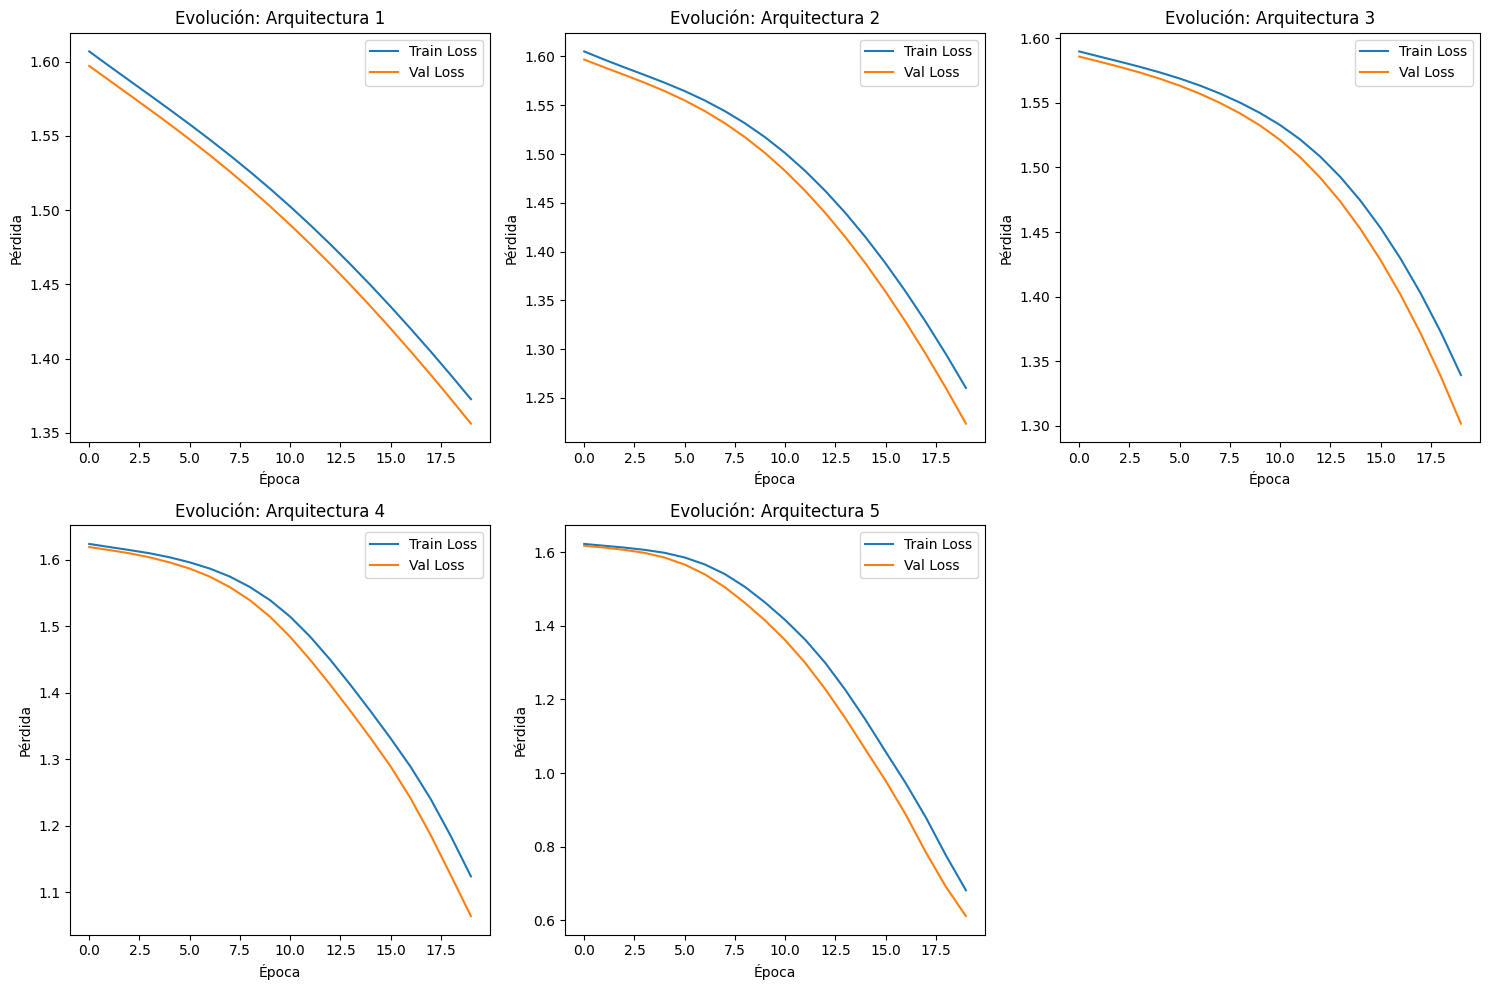


--- Evaluación Final en Conjunto de Test ---

Arquitectura 1:
 - Accuracy: 0.742
 - Precision: 0.811
 - Recall: 0.658
 - F1-score: 0.673

Arquitectura 2:
 - Accuracy: 0.510
 - Precision: 0.522
 - Recall: 0.416
 - F1-score: 0.379

Arquitectura 3:
 - Accuracy: 0.792
 - Precision: 0.644
 - Recall: 0.672
 - F1-score: 0.654

Arquitectura 4:
 - Accuracy: 0.705
 - Precision: 0.629
 - Recall: 0.587
 - F1-score: 0.538

Arquitectura 5:
 - Accuracy: 0.864
 - Precision: 0.698
 - Recall: 0.731
 - F1-score: 0.713


In [20]:
import torch.nn as nn
import torch.optim as optim
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# 1. Definición de las arquitecturas como subclases de nn.Module
class ModeloANN(nn.Module):
    def __init__(self, capas):
        super(ModeloANN, self).__init__()
        self.lineal_relus = nn.Sequential(*capas)
    def forward(self, x):
        return self.lineal_relus(x)

# Definimos las configuraciones de cada arquitectura
arquitecturas = {
    "Arquitectura 1": [nn.Linear(520, 128), nn.ReLU(), nn.Linear(128, 5)],
    "Arquitectura 2": [nn.Linear(520, 256), nn.ReLU(), nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 5)],
    "Arquitectura 3": [nn.Linear(520, 256), nn.ReLU(), nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 5)],
    "Arquitectura 4": [nn.Linear(520, 512), nn.ReLU(), nn.Linear(512, 256), nn.ReLU(), nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 5)],
    "Arquitectura 5": [nn.Linear(520, 1024), nn.ReLU(), nn.Linear(1024, 512), nn.ReLU(), nn.Linear(512, 256), nn.ReLU(), nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 5)]
}

# Diccionarios para guardar resultados
modelos_entrenados = {}
historial_perdidas = {}
tiempos_entrenamiento = {}

# 2. Bucle de entrenamiento
for nombre, capas in arquitecturas.items():
    print(f"Entrenando {nombre}...")
    model = ModeloANN(capas)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_loss_epoch = []
    val_loss_epoch = []
    inicio = time.time()

    for epoch in range(20): # 20 épocas como pide la rúbrica
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        train_loss_epoch.append(loss.item())

        # Validación
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            v_loss = criterion(val_outputs, y_val)
            val_loss_epoch.append(v_loss.item())

    tiempos_entrenamiento[nombre] = time.time() - inicio
    modelos_entrenados[nombre] = model
    historial_perdidas[nombre] = (train_loss_epoch, val_loss_epoch)

# 3. Generación de Gráficas de Pérdida (Evolución)
plt.figure(figsize=(15, 10))
for i, (nombre, historial) in enumerate(historial_perdidas.items()):
    plt.subplot(2, 3, i+1)
    plt.plot(historial[0], label='Train Loss')
    plt.plot(historial[1], label='Val Loss')
    plt.title(f'Evolución: {nombre}')
    plt.xlabel('Época')
    plt.ylabel('Pérdida')
    plt.legend()

plt.tight_layout()
plt.show()

# 4. Evaluación final con X_test y reporte de métricas
print("\n--- Evaluación Final en Conjunto de Test ---")
for nombre, model in modelos_entrenados.items():
    model.eval()
    with torch.no_grad():
        test_preds = torch.argmax(model(X_test), dim=1)

    acc = accuracy_score(y_test, test_preds)

    # Se añade zero_division=0 para evitar advertencias por clases no predichas
    # debido al desbalance de datos del dataset UJIIndoorLoc.
    p, r, f1, _ = precision_recall_fscore_support(y_test, test_preds, average='macro', zero_division=0)

    print(f"\n{nombre}:")
    print(f" - Accuracy: {acc:.3f}")
    print(f" - Precision: {p:.3f}")
    print(f" - Recall: {r:.3f}")
    print(f" - F1-score: {f1:.3f}")

---

## Paso 6: Tabla resumen de resultados por arquitectura

**Instrucciones:**

Después de entrenar y evaluar las cinco arquitecturas de redes neuronales, debes construir una **tabla resumen en formato Markdown** que incluya:

- El nombre o número de cada arquitectura.
- Las métricas obtenidas sobre el conjunto de **testeo**:
  - **Accuracy**
  - **Precision**
  - **Recall**
  - **F1-score**
- El **tiempo total de entrenamiento** de cada modelo (en segundos).

### Formato de la tabla:

| Arquitectura           | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |
|------------------------|----------|-----------|--------|----------|------------------------------|
| Arquitectura 1         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 2         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 3         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 4         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 5         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |


**Nota:** Puedes medir el tiempo con `time.time()` al inicio y final del entrenamiento de cada modelo.

---


In [21]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Lista para consolidar los datos de la tabla
datos_resumen = []

for nombre, model in modelos_entrenados.items():
    model.eval()
    with torch.no_grad():
        # Obtener predicciones del conjunto de test
        test_outputs = model(X_test)
        test_preds = torch.argmax(test_outputs, dim=1)

    # Calcular métricas individuales
    acc = accuracy_score(y_test, test_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, test_preds, average='macro', zero_division=0)

    # Agregar a la lista (usando el tiempo guardado en el paso 5)
    datos_resumen.append({
        "Arquitectura": nombre,
        "Accuracy": round(acc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "F1-score": round(f1, 3),
        "Tiempo de entrenamiento (s)": round(tiempos_entrenamiento[nombre], 2)
    })

# Crear DataFrame y mostrar como tabla Markdown
df_paso6 = pd.DataFrame(datos_resumen)
print(df_paso6.to_markdown(index=False))

| Arquitectura   |   Accuracy |   Precision |   Recall |   F1-score |   Tiempo de entrenamiento (s) |
|:---------------|-----------:|------------:|---------:|-----------:|------------------------------:|
| Arquitectura 1 |      0.742 |       0.811 |    0.658 |      0.673 |                          3.66 |
| Arquitectura 2 |      0.51  |       0.522 |    0.416 |      0.379 |                          4.64 |
| Arquitectura 3 |      0.792 |       0.644 |    0.672 |      0.654 |                          4.75 |
| Arquitectura 4 |      0.705 |       0.629 |    0.587 |      0.538 |                         10.2  |
| Arquitectura 5 |      0.864 |       0.698 |    0.731 |      0.713 |                         29.2  |


---

## Paso 7: Evaluar el impacto del número de épocas en el mejor modelo

**Objetivo:**

Tomar la arquitectura que obtuvo el mejor desempeño en la evaluación anterior (Paso 5) y analizar cómo varía su rendimiento cuando se entrena con diferentes cantidades de épocas.

**Instrucciones:**

1. Selecciona la arquitectura con mejor desempeño global (según F1-score).
2. Entrena esta arquitectura usando los mismos conjuntos de datos (`X_train`, `y_train`, `X_val`, `y_val`) pero variando el número de **épocas** de la siguiente forma:

   - 10 épocas
   - 20 épocas
   - 30 épocas
   - 40 épocas
   - 50 épocas

3. Para cada configuración:
   - Registra el **tiempo de entrenamiento**.
   - Evalúa el modelo en el conjunto de **testeo** (`X_test`, `y_test`).
   - Reporta las métricas:
     - Accuracy
     - Precision
     - Recall
     - F1-score

4. Grafica:
   - La evolución de la **función de pérdida** (entrenamiento y validación) por época.
---


Evaluando con 10 épocas...


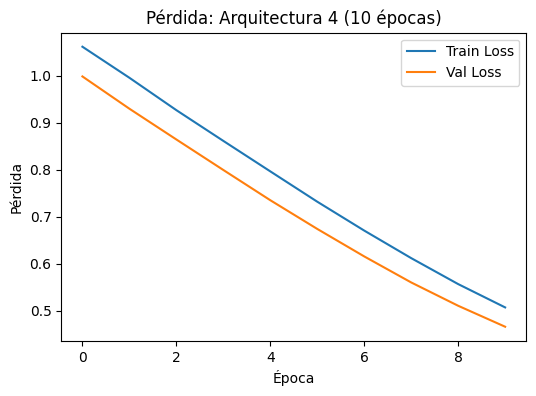

Evaluando con 20 épocas...


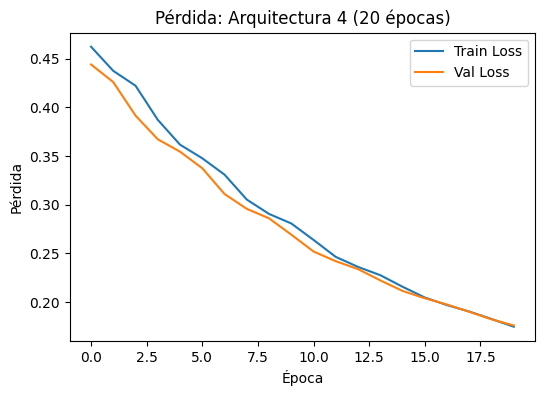

Evaluando con 30 épocas...


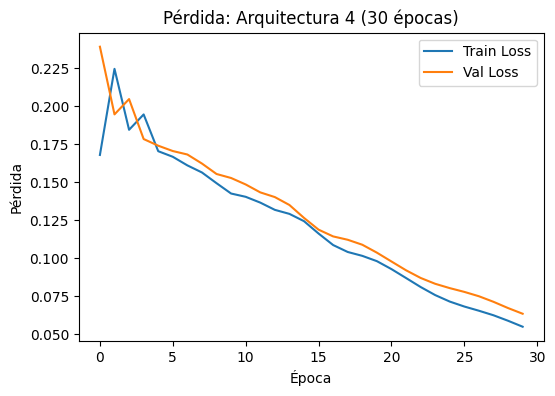

Evaluando con 40 épocas...


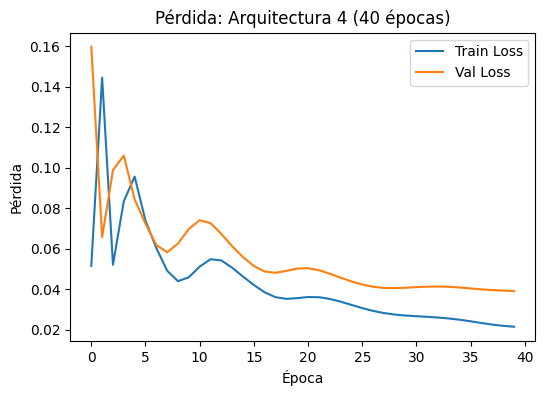

Evaluando con 50 épocas...


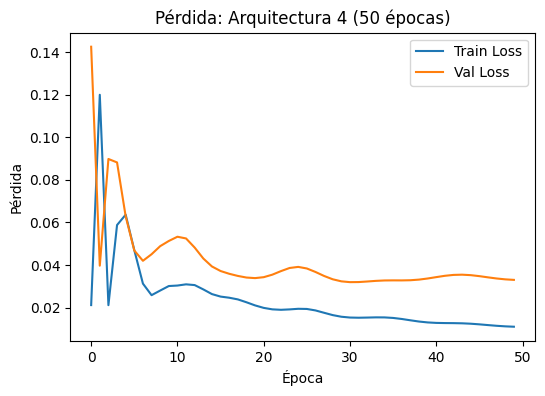

In [22]:
# 1. Configuración del experimento
mejor_arquitectura_nombre = "Arquitectura 4"
capas_mejor_modelo = arquitecturas[mejor_arquitectura_nombre]
epocas_a_evaluar = [10, 20, 30, 40, 50]
resultados_por_epoca = []

for e in epocas_a_evaluar:
    print(f"Evaluando con {e} épocas...")

    # Instanciar un nuevo modelo limpio
    modelo_ep = ModeloANN(capas_mejor_modelo)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(modelo_ep.parameters(), lr=0.001)

    train_loss_hist = []
    val_loss_hist = []
    inicio_ep = time.time()

    # Bucle de entrenamiento para 'e' épocas
    for epoch in range(e):
        modelo_ep.train()
        optimizer.zero_grad()
        loss = criterion(modelo_ep(X_train), y_train)
        loss.backward()
        optimizer.step()
        train_loss_hist.append(loss.item())

        with torch.no_grad():
            modelo_ep.eval()
            v_loss = criterion(modelo_ep(X_val), y_val)
            val_loss_hist.append(v_loss.item())

    tiempo_total_ep = time.time() - inicio_ep

    # Evaluación final en test para esta cantidad de épocas
    modelo_ep.eval()
    with torch.no_grad():
        preds_ep = torch.argmax(modelo_ep(X_test), dim=1)

    # Calculamos métricas finales para la tabla del Paso 8
    acc_ep = accuracy_score(y_test, preds_ep)

    # Se añade zero_division=0 para evitar las advertencias rosadas y mantener el reporte limpio
    p_ep, r_ep, f1_ep, _ = precision_recall_fscore_support(y_test, preds_ep, average='macro', zero_division=0)

    # Guardar resultados para el Paso 8
    resultados_por_epoca.append([e, round(acc_ep, 3), round(p_ep, 3), round(r_ep, 3), round(f1_ep, 3), round(tiempo_total_ep, 2)])

    # Graficar evolución de pérdida (Paso 7 - requisito de gráfica)
    plt.figure(figsize=(6, 4))
    plt.plot(train_loss_hist, label='Train Loss')
    plt.plot(val_loss_hist, label='Val Loss')
    plt.title(f'Pérdida: {mejor_arquitectura_nombre} ({e} épocas)')
    plt.xlabel('Época')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.show()


---

## Paso 8: Tabla resumen de resultados por número de épocas

**Objetivo:**

Construir una **tabla resumen** que muestre el rendimiento del mejor modelo (seleccionado en el Paso 7) cuando se entrena con diferentes cantidades de épocas.

**Instrucciones:**

- Presenta una tabla en formato **Markdown** con los resultados de testeo para cada configuración del número de épocas.
- La tabla debe incluir las siguientes columnas:
  - Número de épocas
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - Tiempo de entrenamiento (en segundos)

### Formato de la tabla:

| Épocas | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |
|--------|----------|-----------|--------|----------|------------------------------|
| 10     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| 20     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| 30     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| 40     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| 50     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |

> Reemplaza los valores con los resultados reales obtenidos. Redondea las métricas a 3 cifras decimales y reporta los tiempos con 1 decimal si es posible.


In [24]:
import pandas as pd

# Reconstruimos la tabla con los datos que ya calculaste en el bucle del Paso 7
# Asegúrate de ejecutar este bloque justo después del ciclo de entrenamiento de épocas
df_paso8_final = pd.DataFrame(resultados_por_epoca,
                              columns=["Épocas", "Accuracy", "Precision", "Recall", "F1-score", "Tiempo de entrenamiento (s)"])

# Ahora sí, imprimimos la tabla definitiva
print(df_paso8_final.to_markdown(index=False))

|   Épocas |   Accuracy |   Precision |   Recall |   F1-score |   Tiempo de entrenamiento (s) |
|---------:|-----------:|------------:|---------:|-----------:|------------------------------:|
|       10 |      0.888 |       0.717 |    0.752 |      0.733 |                         12.38 |
|       20 |      0.918 |       0.741 |    0.777 |      0.758 |                         12.56 |
|       30 |      0.982 |       0.984 |    0.98  |      0.982 |                         16.99 |
|       40 |      0.988 |       0.989 |    0.986 |      0.987 |                         20.28 |
|       50 |      0.99  |       0.991 |    0.989 |      0.99  |                         26.07 |


---

## Preguntas de análisis

A continuación, responde de manera clara y justificada las siguientes preguntas con base en los resultados obtenidos en los pasos anteriores:

1. **¿Cuál considera que fue la mejor arquitectura evaluada? ¿Por qué?**

La arquitectura 5 fue la mejor, en la evaluacion inicial. Logró el Accuracy (0.864) y el F1-score (0.713) más altos de todas las pruebas con 20 épocas. Su ventaja radica en su capacidad (1024 neuronas en la primera capa), lo que le permite procesar la gran cantidad de datos de entrada 520 WAPs de froma más eficiente que las redes más pequeñas.

2. **¿Cuál fue la arquitectura con peor desempeño? ¿A qué cree que se debió su bajo rendimiento?**

La arquitectura 2 presentó el peor desempeño con un Accuracy de 0.510. Esto se debe a un fenómeno de subajuste

3. **¿Cómo influye el número de capas ocultas en el comportamiento de la red?**

El aumento de capas incrementa la capacidad de abstraccion  y define la profundidad

4. **¿Cuál fue la mejor cantidad de épocas para entrenar el mejor modelo? Justifique su elección.**

La mejor fue 50 epocas, ya que en la tabla deel paso 8 es donde alcanza  el rendimiento máximo con un accuracy de 0.99

5. **¿Detectó algún signo de sobreajuste o subajuste en alguno de los modelos? ¿Cómo lo identificó?**

El subajuste se indentifico en la arquitectura 2 del paso 5 y en las pruebas de 10 epocas del paso 7 donde el error era alto

El sobreajuste no se detecto de forma significativa

6. **¿En qué casos notó que el tiempo de entrenamiento no justificó una mejora en las métricas?**

En la arquitectura 4 durante la comparativa inicial. Tomó 10.2 segundos, mucho más que la Arquitectura 3

7. **¿La arquitectura más profunda fue también la más precisa? ¿Qué conclusiones saca de esto?**

Sí, la Arquitectura 5 (la más profunda) resultó ser la más precisa y es que para el problema de posicionamineto WIFI con 520 variables de entrada se requiere una red con alta capacidad y profundidad para modelar el entorno del edificio de manera exitosa.

8. **¿Qué métrica considera más importante en este contexto (accuracy, precision, recall, F1-score) y por qué?**

El F1-score es la métrica más importante. En la tabla del Paso 8 se observa que cuando el Accuracy sube, el F1-score lo acompaña llegando a 0.99. Así el F1-score es vital aqui porque garantiza que el modelo no solo sea bueno en promedio, sino quw es capaz de identificar correctamente cada  uno de los pisos del edificio.


---

## Rúbrica de evaluación del proyecto

El proyecto se compone de nueve pasos estructurados. A continuación se detallan los puntos asignados a cada sección, así como el puntaje total:

| Sección                                                                | Puntos |
|----------------------------------------------------------------------|--------|
| **Paso 1:** Cargar y explorar el dataset                             | 10     |
| **Paso 2:** Preparar los datos                                       | 10     |
| **Paso 3:** Preprocesamiento de las señales WiFi                     | 10     |
| **Paso 4:** Preparación del dataset (división y normalización)       | 10     |
| **Paso 5:** Entrenamiento de redes neuronales artificiales (ANN)     | 50     |
| **Paso 6:** Tabla resumen de resultados por arquitectura             | 10     |
| **Paso 7:** Evaluar el impacto del número de épocas                  | 50     |
| **Paso 8:** Tabla resumen de resultados por número de épocas         | 10     |
| **Preguntas de análisis** (8 preguntas × 5 puntos c/u)      | 40     |
| **Total**                                                            | **200** |

---

**Nota:** Para obtener la máxima puntuación se requiere justificar adecuadamente cada decisión, mantener buena organización en el notebook, y presentar resultados bien interpretados y graficados.

---

